### Trapezoid rule error

We're going to compute the following integral:

$$
    \int_{0}^{\pi} \, \sqrt{\sin(x)} \, dx
$$

We'll use the trapezoid rule. If $h$ is the step size, we can estimate the error as:

$$
    E(h) = \frac{\left| I(h) - I(2h) \right|}{3}
$$

Beware the catastrophic cancellation. Given 2 real numbers $A$ and $B$, the relative error of their difference is bounded by:

$$
    \varepsilon_{A - B} \leq \frac{\varepsilon_{mach}}{2} \, \left( 1 + \frac{\left| A \right| + \left| B \right|}{\left| A - B \right|} \right)
$$

In [1]:
import numpy as np
from scipy.integrate import quad

import matplotlib.pyplot as plt
plt.style.use('dark_background')

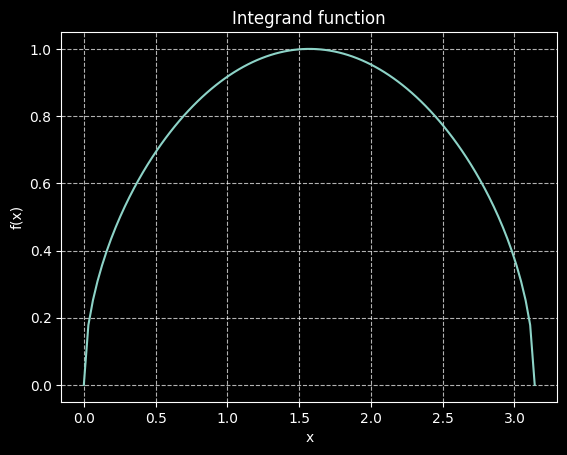

In [2]:
f = lambda x: np.sqrt((np.sin(x))) # Function target

# Fast plot
x = np.linspace(0.0, np.pi, 100)

plt.title("Integrand function")
plt.plot(x, f(x))
plt.grid(linestyle = '--', alpha = 0.7)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

In [3]:
def trapezoid(a, b, h, f): # Computes the integral using np.trapezoid and checks the error

    # Fine
    n = round((b - a) / h)
    x_h = np.linspace(a, b, n + 1)
    y_h = f(x_h)
    I_h = np.trapezoid(y_h, x_h)

    # Coarse
    n_2h = round((b - a) / (2.0 * h))
    x_2h = np.linspace(a, b, n_2h + 1)
    y_2h = f(x_2h)
    I_2h = np.trapezoid(y_2h, x_2h)

    err = np.abs((I_h - I_2h) / 3.0) # Richardson formula
    relative_err_difference = (2.0 + (np.abs(I_h) + np.abs(I_2h)) / np.abs(I_h - I_2h)) * (2 ** (- 53)) # Relative error of the estimated error

    return I_h, err, relative_err_difference

In [4]:
a, b = 0.0, np.pi
h = 1e-02 # Start with h = 0.01
trapezoid(a, b, h, f)

(np.float64(2.3958643805655457),
 np.float64(0.00025359649795160993),
 np.float64(6.993698371700387e-13))

Let's change $h$

In [5]:
h = 10.0 ** (- np.arange(1, 7 + 1, 1)) # h = 1e-01, 1e-02, ... , 1e-07
res = np.array([trapezoid(a, b, h_value, f) for h_value in h])
res

array([[2.38286663e+00, 7.58841761e-03, 2.33527004e-14],
       [2.39586438e+00, 2.53596498e-04, 6.99369837e-13],
       [2.39626732e+00, 8.01175307e-06, 2.21375145e-11],
       [2.39628005e+00, 2.53402135e-07, 6.99916678e-10],
       [2.39628046e+00, 8.01324562e-09, 2.21334016e-08],
       [2.39628047e+00, 2.53401448e-10, 6.99918587e-07],
       [2.39628047e+00, 8.01314570e-12, 2.21336776e-05]])

For $h = 10^{-7}$, the relative error of $\left| I(h) - I(2h) \right| / 3$ is less than $10^{-5}$, then the last value is reliable. We obtained:

$$
    \int_{0}^{\pi} \, \sqrt{\sin(x)} \, dx = 2.396280469458 \pm 0.000000000008
$$

In [6]:
real = quad(f, a, b) # Real value for comparison
print(f"res = {real[0]:.11f} +- {real[1]:.11f}")

res = 2.39628046947 +- 0.00000000002


We can use the error formula to perform a recursive calculation as shown

In [7]:
def adaptive_trapezoid(f, a, b, tol): # Adaptive method

    u = 2 ** (- 53) # Unit roundoff for IEEE 754 double precision

    c = (a + b) / 2.0 # Midpoint of the current interval

    # Coarse approximation
    x_coarse = np.array([a, b])
    y_coarse = f(x_coarse)
    I_coarse = np.trapezoid(y_coarse, x_coarse)

    # Fine approximation
    x_fine = np.array([a, c, b])
    y_fine = f(x_fine)
    I_fine = np.trapezoid(y_fine, x_fine)

    diff = np.abs(I_fine - I_coarse) # Difference between the two estimates
    err_local = diff / 3.0 # Richardson error estimate for the trapezoidal rule:

    if diff == 0.0: # Safety check
        return I_fine, 0.0

    err_err_local = (2.0 + (np.abs(I_fine) + np.abs(I_coarse)) / diff) * u # Catastrophic cancellation monitor

    if (err_local < tol) or (err_err_local > 1e-03): # Stopping criteria
        return I_fine, err_local

    # Recursive refinement
    I_left, err_left = adaptive_trapezoid(f, a, c, tol / 2.0)
    I_right, err_right = adaptive_trapezoid(f, c, b, tol / 2.0)

    return I_left + I_right, err_left + err_right # Returns the sum of the integrals and the sum of the estimated errors

In [8]:
res_adaptive = np.array([adaptive_trapezoid(f, a, b, tol) for tol in 10.0 ** (- np.arange(1, 10 + 1, 1))]) # h = 1e-01, 1e-02, ..., 1e-10
res_adaptive

array([[2.35202714e+00, 3.00376101e-02],
       [2.39056484e+00, 5.61613919e-03],
       [2.39582453e+00, 4.54674389e-04],
       [2.39621564e+00, 6.48194149e-05],
       [2.39627484e+00, 5.63112361e-06],
       [2.39628004e+00, 4.33009551e-07],
       [2.39628040e+00, 6.49108647e-08],
       [2.39628046e+00, 5.54092232e-09],
       [2.39628047e+00, 4.26906993e-10],
       [2.39628047e+00, 6.48319258e-11]])

In [9]:
res_adaptive[-1]

array([2.39628047e+00, 6.48319258e-11])

We obtained:

$$
    \int_{0}^{\pi} \, \sqrt{\sin(x)} \, dx = 2.39628046941 \pm 0.00000000006
$$

In [10]:
print(f"res = {real[0]:.11f} +- {real[1]:.11f}")

res = 2.39628046947 +- 0.00000000002
